In [1]:
import pandas as pd

balanced_train = pd.read_csv(
    "train_fraud_balanced.csv"
)

validation_data = pd.read_csv(
    "validation_fraud.csv"
)

print("Balanced training:", balanced_train.shape)
print("Validation data:", validation_data.shape)

Balanced training: (79328, 45)
Validation data: (8648, 45)


In [2]:
X_train_balanced = balanced_train.drop(
    columns=["is_fraud"]
)

y_train_balanced = balanced_train["is_fraud"]

print("X_train_balanced:", X_train_balanced.shape)
print("y_train_balanced:", y_train_balanced.shape)

X_train_balanced: (79328, 44)
y_train_balanced: (79328,)


In [3]:
feature_columns = X_train_balanced.columns.tolist()

X_validation = validation_data[feature_columns].copy()
y_validation = validation_data["is_fraud"].copy()

y_train_balanced = pd.to_numeric(y_train_balanced, errors="coerce")
y_validation = pd.to_numeric(y_validation, errors="coerce")

valid_train_rows = y_train_balanced.notna()
valid_validation_rows = y_validation.notna()

X_train_balanced = X_train_balanced.loc[valid_train_rows].reset_index(drop=True)
y_train_balanced = y_train_balanced.loc[valid_train_rows].astype(int).reset_index(drop=True)
X_validation = X_validation.loc[valid_validation_rows].reset_index(drop=True)
y_validation = y_validation.loc[valid_validation_rows].astype(int).reset_index(drop=True)

print("Training classes:")
print(y_train_balanced.value_counts())
print("Validation classes:")
print(y_validation.value_counts())

Training classes:
is_fraud
0    39664
1    39664
Name: count, dtype: int64
Validation classes:
is_fraud
0    8499
1     149
Name: count, dtype: int64


In [4]:
for column in feature_columns:
    X_train_balanced[column] = pd.to_numeric(
        X_train_balanced[column],
        errors="coerce"
    )

    X_validation[column] = pd.to_numeric(
        X_validation[column],
        errors="coerce"
    )

# Remove text columns that became completely empty after numeric conversion
usable_columns = X_train_balanced.columns[X_train_balanced.notna().any()].tolist()
X_train_balanced = X_train_balanced[usable_columns].copy()
X_validation = X_validation[usable_columns].copy()

training_medians = X_train_balanced.median()

X_train_balanced = X_train_balanced.fillna(
    training_medians
)

X_validation = X_validation.fillna(
    training_medians
)

print(
    "Training missing values:",
    X_train_balanced.isnull().sum().sum()
)

print(
    "Validation missing values:",
    X_validation.isnull().sum().sum()
)

Training missing values: 0
Validation missing values: 0


In [5]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [6]:
decision_tree_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [7]:
dt_predictions = decision_tree_model.predict(
    X_validation
)

dt_probabilities = decision_tree_model.predict_proba(
    X_validation
)[:, 1]

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [9]:
dt_accuracy = accuracy_score(
    y_validation,
    dt_predictions
)

dt_precision = precision_score(
    y_validation,
    dt_predictions,
    zero_division=0
)

dt_recall = recall_score(
    y_validation,
    dt_predictions,
    zero_division=0
)

dt_f1 = f1_score(
    y_validation,
    dt_predictions,
    zero_division=0
)

dt_roc_auc = roc_auc_score(
    y_validation,
    dt_probabilities
)

print("DECISION TREE RESULTS")
print("---------------------------")
print("Accuracy:", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall:", round(dt_recall, 4))
print("F1 Score:", round(dt_f1, 4))
print("ROC-AUC:", round(dt_roc_auc, 4))

DECISION TREE RESULTS
---------------------------
Accuracy: 0.8484
Precision: 0.0468
Recall: 0.4027
F1 Score: 0.0839
ROC-AUC: 0.614


In [10]:
print(
    classification_report(
        y_validation,
        dt_predictions,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.99      0.86      0.92      8499
       Fraud       0.05      0.40      0.08       149

    accuracy                           0.85      8648
   macro avg       0.52      0.63      0.50      8648
weighted avg       0.97      0.85      0.90      8648



In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotting libraries imported successfully!")

Plotting libraries imported successfully!


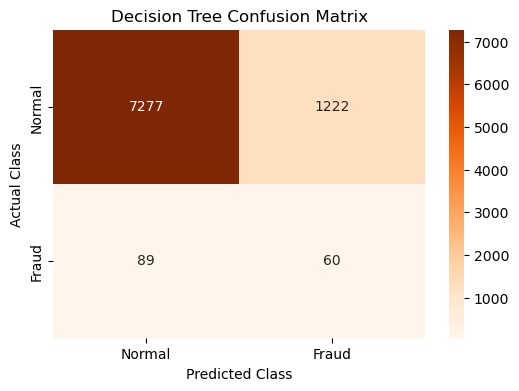

In [12]:
dt_confusion = confusion_matrix(
    y_validation,
    dt_predictions
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    dt_confusion,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [13]:
dt_importance = pd.DataFrame({
    "feature": X_train_balanced.columns,
    "importance": decision_tree_model.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="importance",
    ascending=False
)

dt_importance.head(10)

,feature,importance
5,risk_score,0.473664
4,average_amount_30d,0.126080
15,email_age_days,0.082289
0,amount,0.067635
7,transaction_day,0.051999
14,account_age_days,0.041425
8,transaction_month,0.035030
6,transaction_hour,0.032097
17,customer_balance,0.027609
10,sender_balance_after,0.022594


In [14]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

In [15]:
random_forest_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=1
)

print("Random Forest model created!")

Random Forest model created!


In [16]:
random_forest_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [17]:
print("Model trained:", hasattr(
    random_forest_model,
    "feature_importances_"
))

Model trained: True


In [18]:
rf_importance = pd.DataFrame({
    "feature": X_train_balanced.columns,
    "importance": random_forest_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="importance",
    ascending=False
)

rf_importance.head(10)

,feature,importance
5,risk_score,0.335768
0,amount,0.087581
6,transaction_hour,0.063385
15,email_age_days,0.062777
4,average_amount_30d,0.062265
7,transaction_day,0.061807
8,transaction_month,0.049077
14,account_age_days,0.047032
17,customer_balance,0.033611
3,transactions_last_24h,0.028376


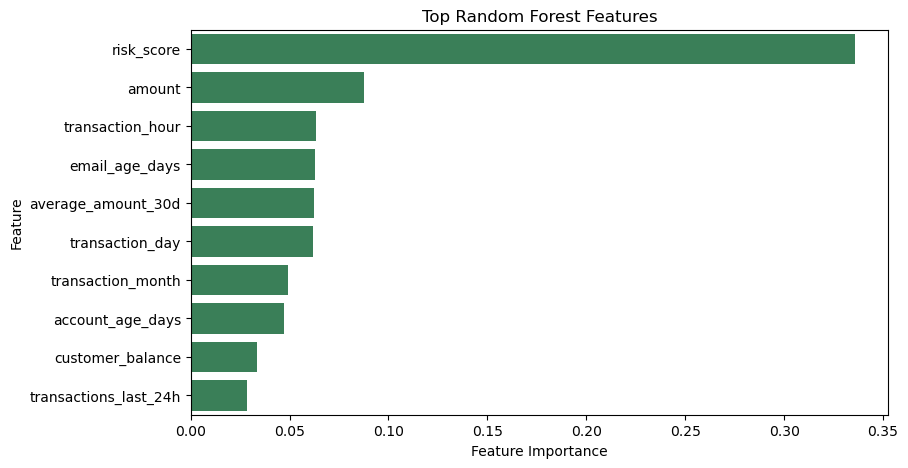

In [19]:
top_rf_features = rf_importance.head(10)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=top_rf_features,
    x="importance",
    y="feature",
    color="seagreen"
)

plt.title("Top Random Forest Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

In [20]:
rf_predictions = random_forest_model.predict(
    X_validation
)

rf_probabilities = random_forest_model.predict_proba(
    X_validation
)[:, 1]

print("Random Forest predictions created!")

Random Forest predictions created!


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_accuracy = accuracy_score(
    y_validation,
    rf_predictions
)

rf_precision = precision_score(
    y_validation,
    rf_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_validation,
    rf_predictions,
    zero_division=0
)

rf_f1 = f1_score(
    y_validation,
    rf_predictions,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_validation,
    rf_probabilities
)

print("RANDOM FOREST RESULTS")
print("---------------------")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1 Score:", round(rf_f1, 4))
print("ROC-AUC:", round(rf_roc_auc, 4))

RANDOM FOREST RESULTS
---------------------
Accuracy: 0.8784
Precision: 0.0552
Recall: 0.3758
F1 Score: 0.0962
ROC-AUC: 0.6506


In [22]:
tree_model_results = pd.DataFrame({
    "model": [
        "Decision Tree",
        "Random Forest"
    ],
    "accuracy": [
        dt_accuracy,
        rf_accuracy
    ],
    "precision": [
        dt_precision,
        rf_precision
    ],
    "recall": [
        dt_recall,
        rf_recall
    ],
    "f1_score": [
        dt_f1,
        rf_f1
    ],
    "roc_auc": [
        dt_roc_auc,
        rf_roc_auc
    ]
})

tree_model_results.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Decision Tree,0.8484,0.0468,0.4027,0.0839,0.6140
1,Random Forest,0.8784,0.0552,0.3758,0.0962,0.6506


In [23]:
# Compare only Decision Tree and Random Forest
all_model_results = tree_model_results.copy()

all_model_results.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Decision Tree,0.8484,0.0468,0.4027,0.0839,0.6140
1,Random Forest,0.8784,0.0552,0.3758,0.0962,0.6506


              precision    recall  f1-score   support

      Normal       0.99      0.89      0.93      8499
       Fraud       0.06      0.38      0.10       149

    accuracy                           0.88      8648
   macro avg       0.52      0.63      0.52      8648
weighted avg       0.97      0.88      0.92      8648



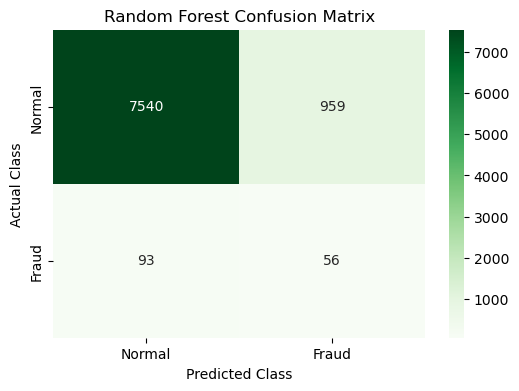

In [24]:
print(classification_report(
    y_validation,
    rf_predictions,
    labels=[0, 1],
    target_names=["Normal", "Fraud"],
    zero_division=0
))

rf_confusion = confusion_matrix(y_validation, rf_predictions, labels=[0, 1])

plt.figure(figsize=(6, 4))
sns.heatmap(
    rf_confusion, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [25]:
best_model_row = all_model_results.loc[
    all_model_results["f1_score"].idxmax()
]

print("Best validation model:",
      best_model_row["model"])

print("Best F1 Score:",
      round(best_model_row["f1_score"], 4))

Best validation model: Random Forest
Best F1 Score: 0.0962


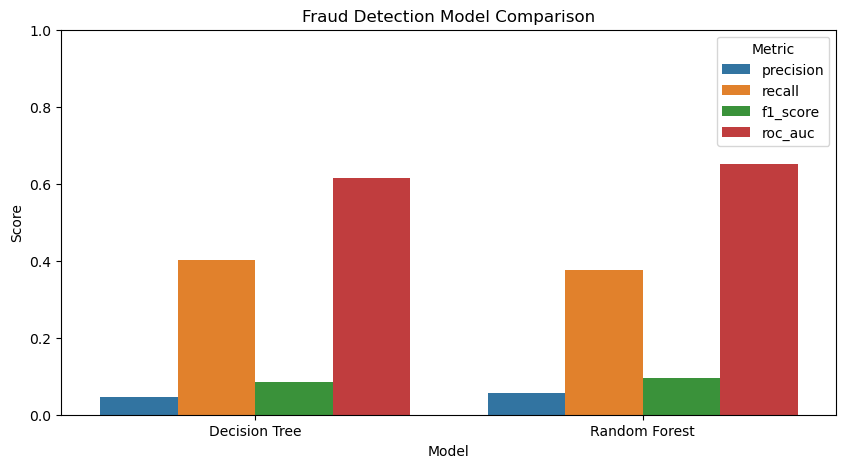

In [26]:
comparison_long = all_model_results.melt(
    id_vars="model",
    value_vars=[
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=comparison_long,
    x="model",
    y="score",
    hue="metric"
)

plt.title("Fraud Detection Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

In [27]:
all_model_results.to_csv(
    "fraud_model_comparison.csv",
    index=False
)

rf_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

print("Model comparison results saved successfully!")

Model comparison results saved successfully!
